# Trabalho T2 — Regressão Múltipla FIFA National Teams
**PUCRS — Escola Politécnica — Análise Multivariada**

**Variável dependente (Y):** `overall_rating`

## 0. Importações e Configurações

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

matplotlib.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 1. Carregamento e Exploração dos Dados

In [4]:
df = pd.read_excel('fifa_world_national_teams.xlsx')

print('=== SHAPE DO DATASET ===')
print(f'Linhas: {df.shape[0]}  |  Colunas: {df.shape[1]}')

print('\n=== PRIMEIRAS LINHAS ===')
df.head()

=== SHAPE DO DATASET ===
Linhas: 718  |  Colunas: 30

=== PRIMEIRAS LINHAS ===


,id,name,full_name,overall_rating,value_euro,wage_euro,nationality,national_team,club_team,age,height_cm,weight_kgs,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),club_rating,Goleiro,Zagueiro,Meio,Atacante,crossing,finishing,heading_accuracy,short_passing,dribbling,jumping,strength,long_shots,aggression,GK_reflexes
0,158023,Messi,Lionel Andrés Messi Cuccittini,94,110500000,565000,Argentina,Argentina,FC Barcelona,31,170.1800,72.1000,5,4,4,86,0,0,0,1,86,95,70,92,97,68,66,94,48,8
1,153079,Aguero,Sergio Leonel Agüero del Castillo,89,64500000,300000,Argentina,Argentina,Manchester City,30,172.7200,69.9000,4,4,4,85,0,0,0,0,70,93,77,81,89,81,73,83,65,14
2,211110,Dybala,Paulo Bruno Exequiel Dybala,89,89000000,205000,Argentina,Argentina,Juventus,25,152.4000,74.8000,3,3,4,85,0,0,0,1,82,84,68,87,92,75,65,88,48,8
3,201399,Icardi,Mauro Emanuel Icardi Rivero,87,64500000,130000,Argentina,Argentina,Inter,26,154.9400,74.8000,3,4,3,82,0,0,0,1,46,91,91,73,77,94,76,70,56,9
4,226226,Lo Celso,Giovani Lo Celso,82,30000000,83000,Argentina,Argentina,Real Betis,22,175.2600,69.9000,1,3,4,80,0,0,0,0,75,77,59,82,84,64,69,76,65,14


In [5]:
print('=== TIPOS DAS VARIÁVEIS ===')
print(df.dtypes)

print('\n=== VALORES FALTANTES ===')
print(df.isnull().sum())

=== TIPOS DAS VARIÁVEIS ===
id                                 int64
name                              object
full_name                         object
overall_rating                     int64
value_euro                         int64
wage_euro                          int64
nationality                       object
national_team                     object
club_team                         object
age                                int64
height_cm                        float64
weight_kgs                       float64
international_reputation(1-5)      int64
weak_foot(1-5)                     int64
skill_moves(1-5)                   int64
club_rating                        int64
Goleiro                            int64
Zagueiro                           int64
Meio                               int64
Atacante                           int64
crossing                           int64
finishing                          int64
heading_accuracy                   int64
short_passing                

In [6]:
print('=== ESTATÍSTICAS DESCRITIVAS ===')
df.describe().T

=== ESTATÍSTICAS DESCRITIVAS ===


,count,mean,std,min,25%,50%,75%,max
id,718.0000,203668.3426,24499.7364,20801.0000,189830.7500,204626.0000,222199.5000,246387.0000
overall_rating,718.0000,76.4610,6.0184,58.0000,72.0000,76.0000,80.0000,94.0000
value_euro,718.0000,13897694.9861,16917513.8080,230000.0000,3325000.0000,8000000.0000,17000000.0000,110500000.0000
wage_euro,718.0000,49559.8886,65224.9078,1000.0000,10000.0000,27000.0000,59000.0000,565000.0000
age,718.0000,26.5655,3.5892,18.0000,24.0000,26.0000,29.0000,37.0000
height_cm,718.0000,642075208913819.7500,3459249650569183.0000,152.4000,170.1800,182.8800,187.9600,19558000000000000.0000
weight_kgs,718.0000,77.6674,7.2907,59.0000,73.0000,77.1000,82.1000,99.8000
international_reputation(1-5),718.0000,1.6727,0.8917,1.0000,1.0000,1.0000,2.0000,5.0000
weak_foot(1-5),718.0000,3.1852,0.7547,1.0000,3.0000,3.0000,4.0000,5.0000
skill_moves(1-5),718.0000,2.7869,0.9524,1.0000,2.0000,3.0000,3.0000,5.0000


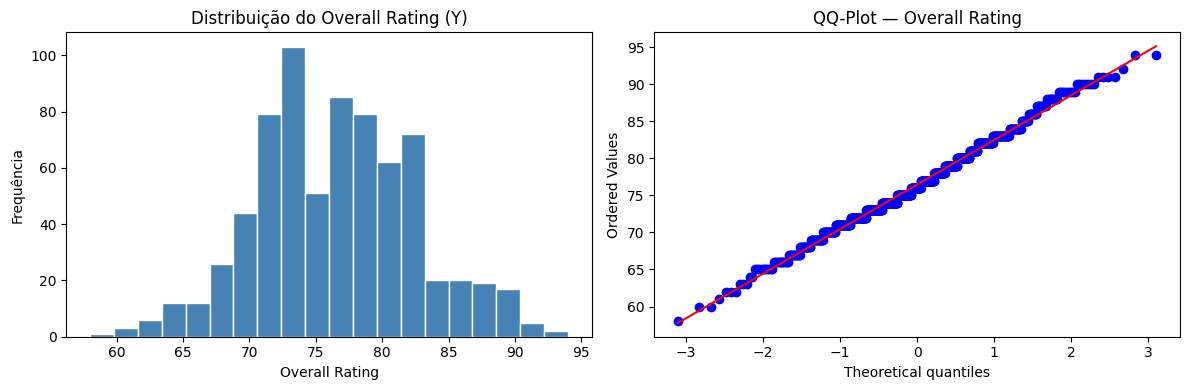

Média: 76.46
Desvio-padrão: 6.02
Min: 58  |  Max: 94


In [7]:
# Distribuição da variável dependente
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['overall_rating'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Overall Rating (Y)')
axes[0].set_xlabel('Overall Rating')
axes[0].set_ylabel('Frequência')

stats.probplot(df['overall_rating'], dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot — Overall Rating')

plt.tight_layout()
plt.show()

print(f'Média: {df["overall_rating"].mean():.2f}')
print(f'Desvio-padrão: {df["overall_rating"].std():.2f}')
print(f'Min: {df["overall_rating"].min()}  |  Max: {df["overall_rating"].max()}')

## 2. Pré-processamento e Engenharia de Features

In [8]:
# ── Cópia de trabalho
data = df.copy()

# ── IMC (Body Mass Index)
data['IMC'] = data['weight_kgs'] / ((data['height_cm'] / 100) ** 2)

# ── Log do valor de mercado (reduz assimetria)
data['log_value'] = np.log1p(data['value_euro'])
data['log_wage']  = np.log1p(data['wage_euro'])

# ── Posição predominante (Goleiro já é binário; Defensor = Zagueiro; etc.)
# já existem: Goleiro, Zagueiro, Meio, Atacante  (0/1)

# ── Mapa de continentes por seleção
continent_map = {
    'Argentina':'América do Sul','Brazil':'América do Sul','Uruguay':'América do Sul',
    'Colombia':'América do Sul','Chile':'América do Sul','Peru':'América do Sul',
    'Paraguay':'América do Sul','Ecuador':'América do Sul','Bolivia':'América do Sul',
    'Venezuela':'América do Sul',
    'Mexico':'América do Norte','United States':'América do Norte','Canada':'América do Norte',
    'Costa Rica':'América Central','Panama':'América Central','Honduras':'América Central',
    'El Salvador':'América Central','Trinidad & Tobago':'Caribe','Jamaica':'Caribe',
    'Germany':'Europa','France':'Europa','Spain':'Europa','England':'Europa',
    'Italy':'Europa','Portugal':'Europa','Belgium':'Europa','Netherlands':'Europa',
    'Croatia':'Europa','Poland':'Europa','Switzerland':'Europa','Denmark':'Europa',
    'Sweden':'Europa','Russia':'Europa','Serbia':'Europa','Czech Republic':'Europa',
    'Austria':'Europa','Wales':'Europa','Scotland':'Europa','Ireland':'Europa',
    'Iceland':'Europa','Greece':'Europa','Romania':'Europa','Hungary':'Europa',
    'Turkey':'Europa','Slovakia':'Europa','Slovenia':'Europa','Ukraine':'Europa',
    'Norway':'Europa','Finland':'Europa','Albania':'Europa','Bosnia Herzegovina':'Europa',
    'Bulgaria':'Europa','Montenegro':'Europa','Northern Ireland':'Europa',
    'Kosovo':'Europa','North Macedonia':'Europa','Armenia':'Europa','Azerbaijan':'Europa',
    'Georgia':'Europa','Kazakhstan':'Europa',
    'Egypt':'África','Nigeria':'África','Senegal':'África','Morocco':'África',
    'Cameroon':'África','Ghana':'África','Tunisia':'África','Ivory Coast':'África',
    'DR Congo':'África','South Africa':'África','Algeria':'África','Mali':'África',
    'Burkina Faso':'África','Cape Verde':'África','Gabon':'África','Benin':'África',
    'Guinea':'África','Congo':'África','Zambia':'África','Mozambique':'África',
    'Tanzania':'África','Zimbabwe':'África','Uganda':'África','Kenya':'África',
    'Japan':'Ásia','South Korea':'Ásia','Iran':'Ásia','Saudi Arabia':'Ásia',
    'Australia':'Oceania','New Zealand':'Oceania',
    'Qatar':'Ásia','UAE':'Ásia','Oman':'Ásia','Iraq':'Ásia','Jordan':'Ásia',
    'Syria':'Ásia','China PR':'Ásia','India':'Ásia','Uzbekistan':'Ásia',
    'Thailand':'Ásia','Vietnam':'Ásia',
}

data['continente'] = data['nationality'].map(continent_map).fillna('Outros')

# ── Dummies de continente (referência: Europa)
dummies_cont = pd.get_dummies(data['continente'], prefix='cont', drop_first=False)
# Remove 'Europa' como referência
if 'cont_Europa' in dummies_cont.columns:
    dummies_cont.drop(columns='cont_Europa', inplace=True)
data = pd.concat([data, dummies_cont], axis=1)

# Converte dummies booleanas para int
for col in [c for c in data.columns if c.startswith('cont_')]:
    data[col] = data[col].astype(int)

print('Variáveis criadas: IMC, log_value, log_wage, dummies de continente')
print('\nDistribuição por continente:')
print(data['continente'].value_counts())

Variáveis criadas: IMC, log_value, log_wage, dummies de continente

Distribuição por continente:
continente
Europa              476
América do Sul      105
América do Norte     52
África               44
Outros               21
Oceania              20
Name: count, dtype: int64


## 3. Modelo Completo — Todas as Variáveis

In [9]:
# ── Variáveis preditoras para o modelo completo
cont_dummies = [c for c in data.columns if c.startswith('cont_')]

features_completo = [
    'age', 'height_cm', 'weight_kgs', 'IMC',
    'log_value', 'log_wage',
    'international_reputation(1-5)', 'weak_foot(1-5)', 'skill_moves(1-5)',
    'club_rating',
    'Goleiro', 'Zagueiro', 'Meio', 'Atacante',
    'crossing', 'finishing', 'heading_accuracy', 'short_passing',
    'dribbling', 'jumping', 'strength', 'long_shots', 'aggression', 'GK_reflexes',
] + cont_dummies

Y = data['overall_rating']
X_completo = data[features_completo].copy()

# Remove colunas constantes ou quasi-constantes
X_completo = X_completo.loc[:, X_completo.std() > 0]

X_completo_sm = sm.add_constant(X_completo)

modelo_completo = sm.OLS(Y, X_completo_sm).fit()

print('=' * 78)
print('       MODELO COMPLETO — REGRESSÃO LINEAR MÚLTIPLA (TODAS AS VARIÁVEIS)')
print('=' * 78)
print(modelo_completo.summary())

       MODELO COMPLETO — REGRESSÃO LINEAR MÚLTIPLA (TODAS AS VARIÁVEIS)
                            OLS Regression Results                            
Dep. Variable:         overall_rating   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1141.
Date:                Mon, 11 May 2026   Prob (F-statistic):          3.05e-223
Time:                        21:24:50   Log-Likelihood:                -1792.5
No. Observations:                 718   AIC:                             3591.
Df Residuals:                     715   BIC:                             3605.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

### 3.1 VIF — Modelo Completo

In [10]:
def calcular_vif(X_df):
    """Calcula VIF para cada variável preditora."""
    X_arr = sm.add_constant(X_df).values
    vif_data = pd.DataFrame()
    vif_data['Variável'] = X_df.columns
    vif_data['VIF'] = [variance_inflation_factor(X_arr, i+1)
                       for i in range(X_df.shape[1])]
    vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
    return vif_data

print('=== VIF — MODELO COMPLETO ===')
vif_completo = calcular_vif(X_completo)
print(vif_completo.to_string(index=False))
print(f'\nVariáveis com VIF > 10 (multicolinearidade severa): '
      f'{(vif_completo["VIF"] > 10).sum()}')

=== VIF — MODELO COMPLETO ===
                     Variável     VIF
                    dribbling 14.8222
                  GK_reflexes 12.3191
                short_passing  7.5842
                   long_shots  7.5482
                    finishing  6.9174
             heading_accuracy  6.4689
                     crossing  5.6595
             skill_moves(1-5)  5.2734
                    log_value  4.1753
                   aggression  3.0584
                     strength  3.0548
                          IMC  2.7824
                    height_cm  2.7793
                     log_wage  2.1063
                   weight_kgs  2.0316
                      Goleiro  1.5955
                  club_rating  1.5729
international_reputation(1-5)  1.4821
                      jumping  1.3720
               weak_foot(1-5)  1.2345
                     Atacante  1.2295
                     Zagueiro  1.2248
                          age  1.1108
                         Meio  1.0718
          cont_Améri

## 4. Simplificação do Modelo

### 4.1 Remoção de variáveis com VIF > 10 e p-valor > 0.05

In [11]:
# Eliminação manual iterativa baseada em VIF alto E p > 0.05
# Removemos variáveis redundantes mantendo interpretabilidade

features_reduzido = [
    'age',
    'log_value',
    'international_reputation(1-5)',
    'skill_moves(1-5)',
    'club_rating',
    'Goleiro',
    'finishing', 'heading_accuracy', 'short_passing',
    'dribbling', 'strength', 'long_shots', 'GK_reflexes',
] + cont_dummies

X_red = data[features_reduzido].copy()
X_red_sm = sm.add_constant(X_red)

modelo_reduzido = sm.OLS(Y, X_red_sm).fit()

print('=' * 70)
print('MODELO REDUZIDO (após remoção de variáveis com VIF > 10)')
print('=' * 70)
print(modelo_reduzido.summary())

MODELO REDUZIDO (após remoção de variáveis com VIF > 10)
                            OLS Regression Results                            
Dep. Variable:         overall_rating   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     1605.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        21:24:50   Log-Likelihood:                -962.31
No. Observations:                 718   AIC:                             1963.
Df Residuals:                     699   BIC:                             2050.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

In [12]:
print('=== VIF — MODELO REDUZIDO ===')
vif_red = calcular_vif(X_red)
print(vif_red.to_string(index=False))
print(f'\nVariáveis com VIF > 10: {(vif_red["VIF"] > 10).sum()}')

=== VIF — MODELO REDUZIDO ===
                     Variável     VIF
                    dribbling 16.9989
                  GK_reflexes 15.0360
                short_passing  7.9606
                   long_shots  7.3504
                    finishing  6.6955
             heading_accuracy  6.2681
             skill_moves(1-5)  5.3377
                    log_value  4.5036
                  club_rating  3.4067
international_reputation(1-5)  2.4519
                     strength  2.1592
                      Goleiro  1.6156
                          age  1.4512
        cont_América do Norte  1.1157
          cont_América do Sul  1.1003
                  cont_África  1.0840
                 cont_Oceania  1.0601
                  cont_Outros  1.0599

Variáveis com VIF > 10: 2


### 4.2 Backward Elimination — Remoção de variáveis não significativas (p > 0.05)

In [13]:
def backward_elimination(Y, X_df, alpha=0.05, verbose=True):
    """Backward elimination baseada no p-valor."""
    cols = list(X_df.columns)
    step = 0
    while True:
        X_sm = sm.add_constant(X_df[cols])
        modelo = sm.OLS(Y, X_sm).fit()
        pvals = modelo.pvalues.drop('const')
        max_p = pvals.max()
        if max_p > alpha:
            rem = pvals.idxmax()
            step += 1
            if verbose:
                print(f'Passo {step}: removendo "{rem}"  (p = {max_p:.4f})')
            cols.remove(rem)
        else:
            break
    if verbose:
        print(f'\nBackward finalizado em {step} passos.')
        print(f'Variáveis mantidas ({len(cols)}): {cols}')
    return cols, modelo

print('=== BACKWARD ELIMINATION (α = 0.05) ===')
cols_final, _ = backward_elimination(Y, X_red)

=== BACKWARD ELIMINATION (α = 0.05) ===
Passo 1: removendo "cont_Oceania"  (p = 0.7939)
Passo 2: removendo "cont_África"  (p = 0.7632)
Passo 3: removendo "Goleiro"  (p = 0.7475)
Passo 4: removendo "dribbling"  (p = 0.4697)
Passo 5: removendo "skill_moves(1-5)"  (p = 0.4663)
Passo 6: removendo "long_shots"  (p = 0.2968)
Passo 7: removendo "cont_Outros"  (p = 0.3126)
Passo 8: removendo "heading_accuracy"  (p = 0.1281)
Passo 9: removendo "strength"  (p = 0.2878)
Passo 10: removendo "cont_América do Norte"  (p = 0.1128)
Passo 11: removendo "short_passing"  (p = 0.0726)

Backward finalizado em 11 passos.
Variáveis mantidas (7): ['age', 'log_value', 'international_reputation(1-5)', 'club_rating', 'finishing', 'GK_reflexes', 'cont_América do Sul']


## 5. Modelo Final

In [14]:
X_final = data[cols_final].copy()
X_final_sm = sm.add_constant(X_final)

modelo_final = sm.OLS(Y, X_final_sm).fit()

print('=' * 70)
print('MODELO FINAL')
print('=' * 70)
print(modelo_final.summary())

MODELO FINAL
                            OLS Regression Results                            
Dep. Variable:         overall_rating   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     4116.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        21:24:50   Log-Likelihood:                -968.72
No. Observations:                 718   AIC:                             1953.
Df Residuals:                     710   BIC:                             1990.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
c

### 5.1 Teste F Global — Modelo Final

In [15]:
print('=' * 60)
print('TESTE F — MODELO FINAL')
print('=' * 60)
print(f'F-statistic  : {modelo_final.fvalue:.4f}')
print(f'Prob (F-stat): {modelo_final.f_pvalue:.4e}')
print(f'Graus de lib. regressão : {modelo_final.df_model:.0f}')
print(f'Graus de lib. resíduo   : {modelo_final.df_resid:.0f}')
if modelo_final.f_pvalue < 0.05:
    print('\n→ CONCLUSÃO: O modelo é estatisticamente significativo (p < 0.05).')
    print('  Ao menos uma variável preditora explica a variação do Overall Rating.')

TESTE F — MODELO FINAL
F-statistic  : 4116.4990
Prob (F-stat): 0.0000e+00
Graus de lib. regressão : 7
Graus de lib. resíduo   : 710

→ CONCLUSÃO: O modelo é estatisticamente significativo (p < 0.05).
  Ao menos uma variável preditora explica a variação do Overall Rating.


### 5.2 Testes t — Coeficientes Individuais

In [16]:
print('=' * 70)
print('TESTES t — COEFICIENTES INDIVIDUAIS (MODELO FINAL)')
print('=' * 70)

ttest_df = pd.DataFrame({
    'Coeficiente'  : modelo_final.params,
    'Erro Padrão'  : modelo_final.bse,
    't-statistic'  : modelo_final.tvalues,
    'p-valor'      : modelo_final.pvalues,
    'IC 2.5%'      : modelo_final.conf_int()[0],
    'IC 97.5%'     : modelo_final.conf_int()[1],
    'Significativo': modelo_final.pvalues.apply(lambda p: '***' if p<0.001
                                                  else ('**' if p<0.01
                                                  else ('*' if p<0.05 else '')))
})
print(ttest_df.to_string())
print('\nNível de significância: *** p<0.001  ** p<0.01  * p<0.05')

TESTES t — COEFICIENTES INDIVIDUAIS (MODELO FINAL)
                               Coeficiente  Erro Padrão  t-statistic  p-valor  IC 2.5%  IC 97.5% Significativo
const                              -4.2690       0.8166      -5.2275   0.0000  -5.8723   -2.6657           ***
age                                 0.2871       0.0111      25.8421   0.0000   0.2653    0.3089           ***
log_value                           4.3214       0.0535      80.8458   0.0000   4.2164    4.4263           ***
international_reputation(1-5)       0.6855       0.0605      11.3285   0.0000   0.5667    0.8043           ***
club_rating                         0.0568       0.0121       4.7098   0.0000   0.0331    0.0804           ***
finishing                          -0.0155       0.0023      -6.6311   0.0000  -0.0201   -0.0109           ***
GK_reflexes                         0.0061       0.0022       2.7898   0.0054   0.0018    0.0104            **
cont_América do Sul                 0.3594       0.1015      

### 5.3 VIF — Modelo Final

VIF — MODELO FINAL
                     Variável    VIF
                    log_value 3.4643
                  club_rating 3.2809
international_reputation(1-5) 2.3732
                    finishing 2.1697
                  GK_reflexes 1.9221
                          age 1.2961
          cont_América do Sul 1.0495

VIF máximo   : 3.46
VIF > 10     : 0 variável(is)
VIF > 5      : 0 variável(is)


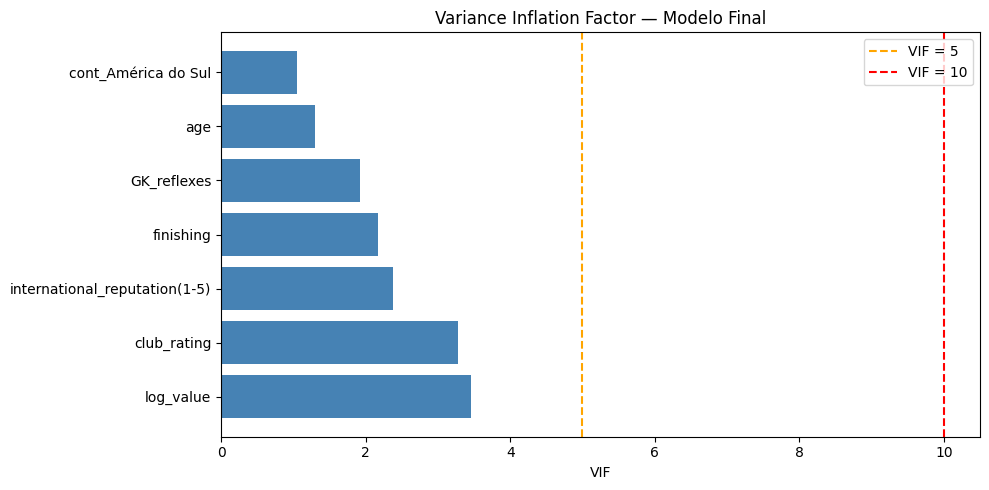

In [17]:
print('=' * 60)
print('VIF — MODELO FINAL')
print('=' * 60)
vif_final = calcular_vif(X_final)
print(vif_final.to_string(index=False))

print(f'\nVIF máximo   : {vif_final["VIF"].max():.2f}')
print(f'VIF > 10     : {(vif_final["VIF"] > 10).sum()} variável(is)')
print(f'VIF > 5      : {(vif_final["VIF"] > 5).sum()} variável(is)')

# Gráfico VIF
plt.figure(figsize=(10, 5))
colors = ['red' if v > 10 else ('orange' if v > 5 else 'steelblue')
          for v in vif_final['VIF']]
plt.barh(vif_final['Variável'], vif_final['VIF'], color=colors)
plt.axvline(x=5,  color='orange', linestyle='--', label='VIF = 5')
plt.axvline(x=10, color='red',    linestyle='--', label='VIF = 10')
plt.xlabel('VIF')
plt.title('Variance Inflation Factor — Modelo Final')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Análise de Resíduos

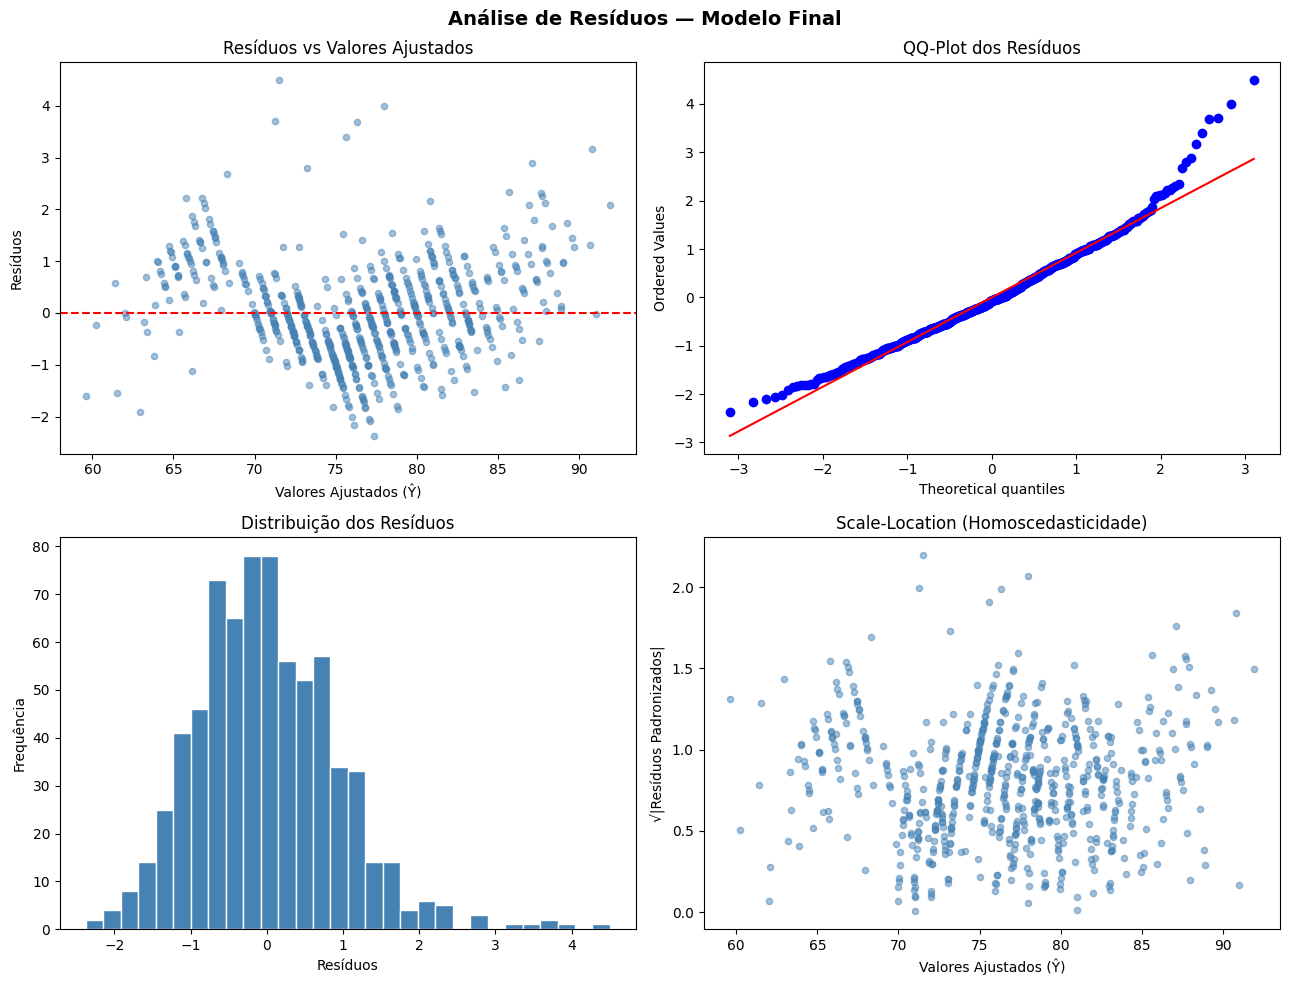

In [18]:
residuos   = modelo_final.resid
fitted     = modelo_final.fittedvalues
residuos_std = residuos / residuos.std()   # resíduos padronizados

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Análise de Resíduos — Modelo Final', fontsize=14, fontweight='bold')

# 1) Resíduos vs Valores Ajustados
axes[0, 0].scatter(fitted, residuos, alpha=0.5, color='steelblue', s=20)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Valores Ajustados (Ŷ)')
axes[0, 0].set_ylabel('Resíduos')
axes[0, 0].set_title('Resíduos vs Valores Ajustados')

# 2) QQ-Plot dos Resíduos
stats.probplot(residuos, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('QQ-Plot dos Resíduos')

# 3) Histograma dos Resíduos
axes[1, 0].hist(residuos, bins=30, color='steelblue', edgecolor='white')
axes[1, 0].set_xlabel('Resíduos')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_title('Distribuição dos Resíduos')

# 4) Scale-Location (√|Resíduos std| vs Ajustados)
axes[1, 1].scatter(fitted, np.sqrt(np.abs(residuos_std)), alpha=0.5, color='steelblue', s=20)
axes[1, 1].set_xlabel('Valores Ajustados (Ŷ)')
axes[1, 1].set_ylabel('√|Resíduos Padronizados|')
axes[1, 1].set_title('Scale-Location (Homoscedasticidade)')

plt.tight_layout()
plt.show()

In [19]:
# Teste de Normalidade dos Resíduos
print('=' * 60)
print('TESTES DE NORMALIDADE DOS RESÍDUOS')
print('=' * 60)

# Shapiro-Wilk
stat_sw, p_sw = stats.shapiro(residuos)
print(f'\nShapiro-Wilk:')
print(f'  W = {stat_sw:.4f}   |   p-valor = {p_sw:.4e}')
print(f'  → {"Normalidade rejeitada (p < 0.05)" if p_sw < 0.05 else "Não há evidência contra normalidade"}')

# Kolmogorov-Smirnov
stat_ks, p_ks = stats.kstest(residuos, 'norm',
                              args=(residuos.mean(), residuos.std()))
print(f'\nKolmogorov-Smirnov:')
print(f'  D = {stat_ks:.4f}   |   p-valor = {p_ks:.4e}')
print(f'  → {"Normalidade rejeitada (p < 0.05)" if p_ks < 0.05 else "Não há evidência contra normalidade"}')

# Jarque-Bera
stat_jb, p_jb = stats.jarque_bera(residuos)
print(f'\nJarque-Bera:')
print(f'  JB = {stat_jb:.4f}   |   p-valor = {p_jb:.4e}')
print(f'  → {"Normalidade rejeitada (p < 0.05)" if p_jb < 0.05 else "Não há evidência contra normalidade"}')

print(f'\nAssimetria (skewness): {stats.skew(residuos):.4f}')
print(f'Curtose (kurtosis)   : {stats.kurtosis(residuos):.4f}')

TESTES DE NORMALIDADE DOS RESÍDUOS

Shapiro-Wilk:
  W = 0.9744   |   p-valor = 6.7787e-10
  → Normalidade rejeitada (p < 0.05)

Kolmogorov-Smirnov:
  D = 0.0504   |   p-valor = 5.0480e-02
  → Não há evidência contra normalidade

Jarque-Bera:
  JB = 133.8353   |   p-valor = 8.6705e-30
  → Normalidade rejeitada (p < 0.05)

Assimetria (skewness): 0.6991
Curtose (kurtosis)   : 1.5870


In [20]:
# Durbin-Watson — Autocorrelação dos Resíduos
print('=' * 60)
print('TESTE DE DURBIN-WATSON (Autocorrelação)')
print('=' * 60)
dw = durbin_watson(residuos)
print(f'Durbin-Watson: {dw:.4f}')
if 1.5 < dw < 2.5:
    print('→ Sem evidência de autocorrelação (valor entre 1.5 e 2.5).')
elif dw <= 1.5:
    print('→ Possível autocorrelação POSITIVA.')
else:
    print('→ Possível autocorrelação NEGATIVA.')

TESTE DE DURBIN-WATSON (Autocorrelação)
Durbin-Watson: 1.3991
→ Possível autocorrelação POSITIVA.


## 7. Teste de Heterocedasticidade

In [21]:
print('=' * 60)
print('TESTE DE BREUSCH-PAGAN (Heterocedasticidade)')
print('=' * 60)

bp_stat, bp_pval, bp_f, bp_fpval = het_breuschpagan(residuos, X_final_sm)
print(f'LM Statistic : {bp_stat:.4f}')
print(f'LM p-valor   : {bp_pval:.4e}')
print(f'F-statistic  : {bp_f:.4f}')
print(f'F p-valor    : {bp_fpval:.4e}')
if bp_pval < 0.05:
    print('\n→ CONCLUSÃO: Heterocedasticidade DETECTADA (p < 0.05).')
    print('  Os resíduos não possuem variância constante.')
else:
    print('\n→ CONCLUSÃO: Sem evidência de heterocedasticidade (p ≥ 0.05).')

print()
print('=' * 60)
print('TESTE DE WHITE (Heterocedasticidade)')
print('=' * 60)

try:
    w_stat, w_pval, w_f, w_fpval = het_white(residuos, X_final_sm)
    print(f'LM Statistic : {w_stat:.4f}')
    print(f'LM p-valor   : {w_pval:.4e}')
    print(f'F-statistic  : {w_f:.4f}')
    print(f'F p-valor    : {w_fpval:.4e}')
    if w_pval < 0.05:
        print('\n→ CONCLUSÃO: Heterocedasticidade DETECTADA (p < 0.05).')
    else:
        print('\n→ CONCLUSÃO: Sem evidência de heterocedasticidade (p ≥ 0.05).')
except Exception as e:
    print(f'(Teste de White não pôde ser executado: {e})')

TESTE DE BREUSCH-PAGAN (Heterocedasticidade)
LM Statistic : 65.4704
LM p-valor   : 1.2096e-11
F-statistic  : 10.1766
F p-valor    : 3.5369e-12

→ CONCLUSÃO: Heterocedasticidade DETECTADA (p < 0.05).
  Os resíduos não possuem variância constante.

TESTE DE WHITE (Heterocedasticidade)
LM Statistic : 197.0900
LM p-valor   : 7.1770e-25
F-statistic  : 7.6005
F p-valor    : 7.3309e-30

→ CONCLUSÃO: Heterocedasticidade DETECTADA (p < 0.05).


## 8. Resumo Comparativo dos Modelos

In [22]:
print('=' * 70)
print('COMPARATIVO DOS MODELOS')
print('=' * 70)

comparativo = pd.DataFrame({
    'Modelo'      : ['Completo', 'Reduzido (sem VIF>10)', 'Final (backward)'],
    'Nº Variáveis': [len(features_completo), len(features_reduzido), len(cols_final)],
    'R²'          : [modelo_completo.rsquared,  modelo_reduzido.rsquared,  modelo_final.rsquared],
    'R² Ajustado' : [modelo_completo.rsquared_adj, modelo_reduzido.rsquared_adj, modelo_final.rsquared_adj],
    'AIC'         : [modelo_completo.aic,  modelo_reduzido.aic,  modelo_final.aic],
    'BIC'         : [modelo_completo.bic,  modelo_reduzido.bic,  modelo_final.bic],
    'F-statistic' : [modelo_completo.fvalue, modelo_reduzido.fvalue, modelo_final.fvalue],
    'Prob(F)'     : [modelo_completo.f_pvalue, modelo_reduzido.f_pvalue, modelo_final.f_pvalue],
})

print(comparativo.to_string(index=False))

COMPARATIVO DOS MODELOS
               Modelo  Nº Variáveis     R²  R² Ajustado       AIC       BIC  F-statistic  Prob(F)
             Completo            29 0.7615       0.7608 3590.9309 3604.6603    1141.1438   0.0000
Reduzido (sem VIF>10)            18 0.9764       0.9758 1962.6143 2049.5672    1605.1513   0.0000
     Final (backward)             7 0.9760       0.9757 1953.4341 1990.0458    4116.4990   0.0000


## 9. Valores Ajustados vs Observados — Modelo Final

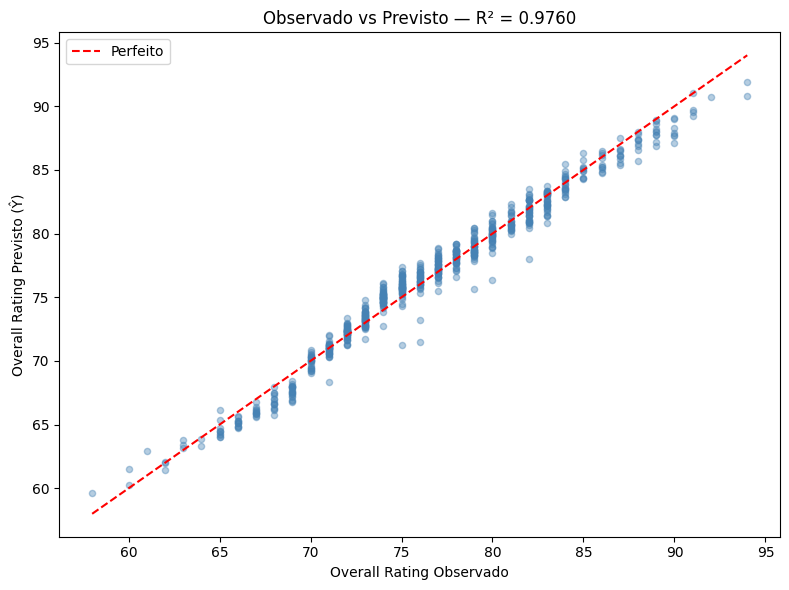

RMSE : 0.9326
MAE  : 0.7222
R²   : 0.9760
R² Aj: 0.9757


In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(Y, fitted, alpha=0.4, color='steelblue', s=20)
mn, mx = Y.min(), Y.max()
plt.plot([mn, mx], [mn, mx], 'r--', label='Perfeito')
plt.xlabel('Overall Rating Observado')
plt.ylabel('Overall Rating Previsto (Ŷ)')
plt.title(f'Observado vs Previsto — R² = {modelo_final.rsquared:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean(residuos**2))
mae  = np.mean(np.abs(residuos))
print(f'RMSE : {rmse:.4f}')
print(f'MAE  : {mae:.4f}')
print(f'R²   : {modelo_final.rsquared:.4f}')
print(f'R² Aj: {modelo_final.rsquared_adj:.4f}')

## 10. Equação do Modelo Final

In [24]:
print('=' * 70)
print('EQUAÇÃO DO MODELO FINAL')
print('=' * 70)

params = modelo_final.params
intercept = params['const']
eq = f'Overall_Rating = {intercept:.4f}'
for var, coef in params.drop('const').items():
    sinal = '+' if coef >= 0 else '-'
    eq += f'\n               {sinal} {abs(coef):.4f} × {var}'

print(eq)
print(f'\nR² = {modelo_final.rsquared:.4f}  |  R² Ajustado = {modelo_final.rsquared_adj:.4f}')
print(f'F({modelo_final.df_model:.0f}, {modelo_final.df_resid:.0f}) = {modelo_final.fvalue:.2f}  |  p = {modelo_final.f_pvalue:.2e}')

EQUAÇÃO DO MODELO FINAL
Overall_Rating = -4.2690
               + 0.2871 × age
               + 4.3214 × log_value
               + 0.6855 × international_reputation(1-5)
               + 0.0568 × club_rating
               - 0.0155 × finishing
               + 0.0061 × GK_reflexes
               + 0.3594 × cont_América do Sul

R² = 0.9760  |  R² Ajustado = 0.9757
F(7, 710) = 4116.50  |  p = 0.00e+00
